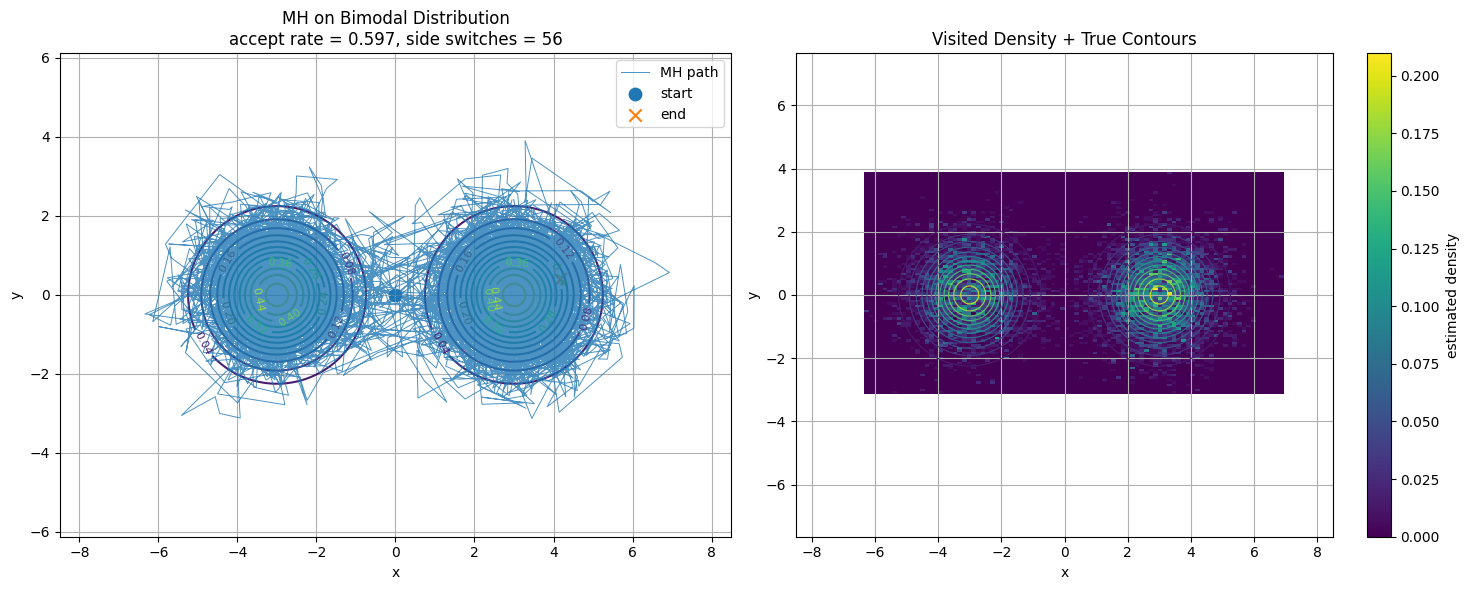

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 設定
# =========================================
np.random.seed(42)
n_steps = 12000
proposal_std = 0.9

# =========================================
# 二峰性分布
# 2つの2次元ガウスの混合
#   0.5 * N(mu1, I) + 0.5 * N(mu2, I)
# mu1 = (-3, 0), mu2 = (3, 0)
# =========================================
mu1 = np.array([-3.0, 0.0])
mu2 = np.array([ 3.0, 0.0])

def gaussian_2d(x, mu):
    diff = x - mu
    return np.exp(-0.5 * np.sum(diff**2))

def target_density_point(x):
    return 0.5 * gaussian_2d(x, mu1) + 0.5 * gaussian_2d(x, mu2)

def log_target(x):
    val = target_density_point(x)
    return np.log(val + 1e-300)   # log(0)回避

def target_density_grid(X, Y):
    Z1 = np.exp(-0.5 * ((X - mu1[0])**2 + (Y - mu1[1])**2))
    Z2 = np.exp(-0.5 * ((X - mu2[0])**2 + (Y - mu2[1])**2))
    return 0.5 * Z1 + 0.5 * Z2

# =========================================
# Metropolis-Hastings
# =========================================
mh = np.zeros((n_steps, 2))
current = np.array([0.0, 0.0])
accepted = 0

for t in range(1, n_steps):
    proposal = current + np.random.normal(0, proposal_std, size=2)

    log_alpha = log_target(proposal) - log_target(current)

    if np.log(np.random.rand()) < log_alpha:
        current = proposal
        accepted += 1

    mh[t] = current

accept_rate = accepted / (n_steps - 1)

# =========================================
# 等高線グリッド
# =========================================
x = np.linspace(-7, 7, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)
Z = target_density_grid(X, Y)

# =========================================
# 左右どちらの山にいたか確認用
# =========================================
side = np.where(mh[:, 0] < 0, -1, 1)
switches = np.sum(side[1:] != side[:-1])

# =========================================
# 描画
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- 左: 等高線 + 軌跡 ----
cs = axes[0].contour(X, Y, Z, levels=12)
axes[0].clabel(cs, inline=True, fontsize=8)

axes[0].plot(mh[:, 0], mh[:, 1], linewidth=0.7, alpha=0.8, label="MH path")
axes[0].scatter(mh[0, 0], mh[0, 1], s=80, marker='o', label='start')
axes[0].scatter(mh[-1, 0], mh[-1, 1], s=80, marker='x', label='end')

axes[0].set_title(
    f"MH on Bimodal Distribution\naccept rate = {accept_rate:.3f}, side switches = {switches}"
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")
axes[0].grid(True)
axes[0].legend()

# ---- 右: 訪問密度 ----
h = axes[1].hist2d(mh[:, 0], mh[:, 1], bins=90, density=True)
axes[1].contour(X, Y, Z, levels=12, linewidths=0.8)
axes[1].set_title("Visited Density + True Contours")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].grid(True)

plt.colorbar(h[3], ax=axes[1], label="estimated density")
plt.tight_layout()
plt.show()